Customer Segmentation Analysis

Name: Venecia Dsouza
Project Type: Data Analytics Internship
Task: Customer Segmentation using K-Means

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("ifood_df.csv")
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [ ]:
df.shape

(2205, 39)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 2205 entries, 0 to 2204
,Data columns (total 39 columns):
, #   Column                Non-Null Count  Dtype  
,---  ------                --------------  -----  
, 0   Income                2205 non-null   float64
, 1   Kidhome               2205 non-null   int64  
, 2   Teenhome              2205 non-null   int64  
, 3   Recency               2205 non-null   int64  
, 4   MntWines              2205 non-null   int64  
, 5   MntFruits             2205 non-null   int64  
, 6   MntMeatProducts       2205 non-null   int64  
, 7   MntFishProducts       2205 non-null   int64  
, 8   MntSweetProducts      2205 non-null   int64  
, 9   MntGoldProds          2205 non-null   int64  
, 10  NumDealsPurchases     2205 non-null   int64  
, 11  NumWebPurchases       2205 non-null   int64  
, 12  NumCatalogPurchases   2205 non-null   int64  
, 13  NumStorePurchases     2205 non-null   int64  
, 14  NumWebVisitsMonth     2205 non-null   int64  
, 15  A

In [ ]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married',
       'marital_Single', 'marital_Together', 'marital_Widow',
       'education_2n Cycle', 'education_Basic', 'education_Graduation',
       'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds',
       'AcceptedCmpOverall'],
      dtype='object')

The dataset contains customer demographic information and purchasing behavior, which will be used for customer segmentation analysis

In [ ]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,...,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000
mean,51687.258783,0.443345,0.509649,48.880752,306.492331,26.364671,166.059871,37.603662,27.268679,43.921821,...,0.251856,0.034636,0.090549,0.024245,0.502227,0.165760,0.217219,563.789213,519.867392,0.302326
std,20713.046401,0.536196,0.546393,28.950917,337.603877,39.776518,219.869126,54.892196,41.575454,51.678211,...,0.434186,0.182902,0.287038,0.153848,0.500119,0.371957,0.412455,576.775749,554.797857,0.680812
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.000000
25%,35416.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,42.000000,0.000000
50%,51412.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.000000
75%,68274.000000,1.000000,1.000000,74.000000,507.000000,33.000000,230.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,883.000000,0.000000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.000000


Descriptive statistics were calculated to understand customer spending, frequency of purchases, and other key behavioral metrics.

In [ ]:
features = df[['Income', 'Recency', 'NumWebPurchases', 'NumStorePurchases', 'MntWines']]

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

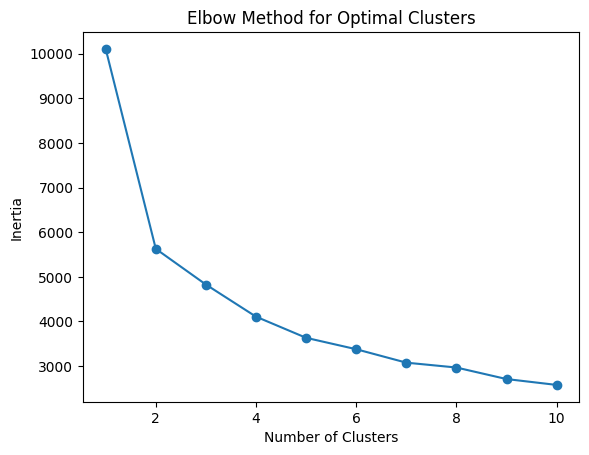

In [ ]:
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

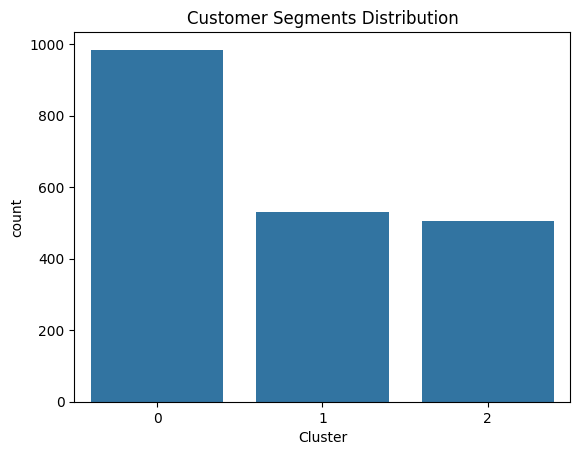

In [ ]:
sns.countplot(x='Cluster', data=df)
plt.title("Customer Segments Distribution")
plt.show()

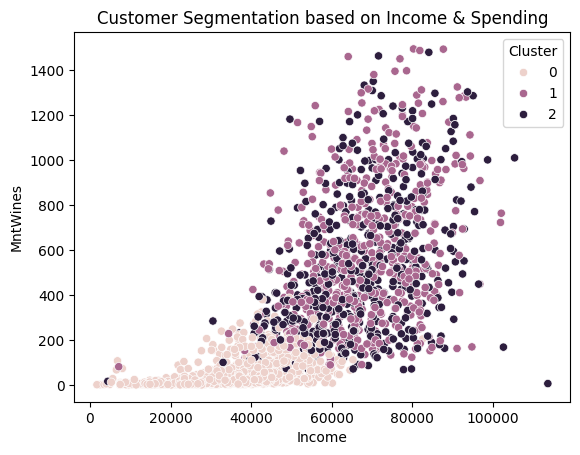

In [ ]:
sns.scatterplot(
    x='Income',
    y='MntWines',
    hue='Cluster',
    data=df
)
plt.title("Customer Segmentation based on Income & Spending")
plt.show()

In [ ]:
df.groupby('Cluster').mean()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
Cluster,,,,,,,,,,,,,,,,,,,,,
0,34718.354675,0.762195,0.475610,49.535569,48.362805,5.802846,28.836382,8.867886,5.951220,18.802846,...,0.258130,0.024390,0.105691,0.048780,0.485772,0.171748,0.188008,97.821138,79.018293,0.093496
1,68254.374765,0.129944,0.546139,73.444444,581.591337,45.263653,305.576271,65.465160,49.967985,68.483992,...,0.231638,0.045198,0.062147,0.001883,0.516008,0.156309,0.263653,1047.864407,979.380414,0.500942
2,67300.426877,0.152174,0.537549,21.830040,519.776680,46.517787,286.503953,64.247036,44.903162,66.994071,...,0.260870,0.043478,0.090909,0.000000,0.519763,0.164032,0.225296,961.948617,894.954545,0.500000


Each cluster represents a distinct customer segment with different income levels, purchasing frequency, and spending behavior.

Insights & Recommendations:
High-value customers should be targeted with personalized offers.
Medium-spending customers can be encouraged through loyalty programs.
Low-spending customers may respond to discounts and promotional campaigns.
Customer segmentation helps improve targeted marketing and customer satisfaction.